## 1. What this notebook computes

A condensate (a field that depends on the time $x_4$ only) has the same energy
density and pressure in every direction. That does not yet make it a *perfect
fluid*: a perfect fluid at rest has a diagonal energy-momentum tensor, and the
spin connection of the author's metric puts entries off the diagonal. This
notebook computes all 64 entries of the tensor of exact condensates of
dirac16complex00 and

- shows the tensor of a generic condensate as a heat map and counts its nonzero
  off-diagonal entries: 42 on the deflating history, 12 when $a_4' = 0$;
- shows how these entries depend on the deflation rate $a_4'$;
- checks that each of the 42 entries is a multiple of one of 15 *three-gamma
  bilinears* $\bar\Phi\gamma^{(a)}\gamma^{(b)}\gamma^{(c)}\Phi$;
- builds the exact condensates of the Revision record for which all 15
  bilinears vanish, and checks that their tensor is diagonal at 36 points with
  different $a_4$, $a_4'$ and $z$ (the record states it for all of them);
- tests the conservation $\nabla_\mu T^\mu{}_\nu = 0$ of the full tensor of a
  condensate along a curved (non-linear) history with finite differences whose
  step shrinks, and contrasts it with a configuration that leaves out the
  gravitational term $3H\gamma^{(8)}$ of the field equation (a negative control);
- draws five teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 09c (The full energy-momentum tensor of a condensate) is the file
`Revision/textbook/notebooks/09c_condensate_tensor.ipynb` of the repository Dirac_claude.
It computes all 64 entries of the energy-momentum tensor of exact condensates of the
commuting field dirac16complex00 in the author's metric, including the off-diagonal
entries that the spin connection produces, finds the 42 nonzero off-diagonal entries of a
generic condensate and checks that each is a multiple of one of 15 three-gamma bilinears,
builds the exact condensates whose tensor is diagonal, and tests the conservation of the
full tensor along a curved history with finite differences of shrinking step, with a
negative control that leaves out the gravitational term of the field equation; five
teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 09c_condensate_tensor.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 09c_condensate_tensor.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
09c_condensate_tensor.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/09c.captions.json`
- `Revision/textbook/figures/09c_1_generic_condensate.png`
- `Revision/textbook/figures/09c_2_offdiagonal_entries.png`
- `Revision/textbook/figures/09c_3_witness_condensate.png`
- `Revision/textbook/figures/09c_4_conservation_convergence.png`
- `Revision/textbook/figures/09c_5_divergence_components.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the five figures of this notebook are saved and captioned
    ALL 20 CHECKS PASSED (notebook 09c)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/09c_condensate_tensor.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "KeyError" with the words "has no check": the notebook asks a Revision report for the
  verdict of one of its checks, and the report in your copy of the repository does not
  contain that check: your copy is older or newer than the notebook. Run `git pull` in
  the repository folder, then run the notebook again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 09c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 09c (The full energy-momentum tensor of a condensate) is the file
# Revision/textbook/notebooks/09c_condensate_tensor.ipynb of the repository Dirac_claude.
# It computes all 64 entries of the energy-momentum tensor of exact condensates of the
# commuting field dirac16complex00 in the author's metric, including the off-diagonal
# entries that the spin connection produces, finds the 42 nonzero off-diagonal entries of
# a generic condensate and checks that each is a multiple of one of 15 three-gamma
# bilinears, builds the exact condensates whose tensor is diagonal, and tests the
# conservation of the full tensor along a curved history with finite differences of
# shrinking step, with a negative control that leaves out the gravitational term of the
# field equation; five teaching plots. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 09c_condensate_tensor.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 09c_condensate_tensor.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 09c_condensate_tensor.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/09c.captions.json
# - Revision/textbook/figures/09c_1_generic_condensate.png
# - Revision/textbook/figures/09c_2_offdiagonal_entries.png
# - Revision/textbook/figures/09c_3_witness_condensate.png
# - Revision/textbook/figures/09c_4_conservation_convergence.png
# - Revision/textbook/figures/09c_5_divergence_components.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the five figures of this notebook are saved and captioned
#     ALL 20 CHECKS PASSED (notebook 09c)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/09c_condensate_tensor.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "KeyError" with the words "has no check": the notebook asks a Revision report for the
#   verdict of one of its checks, and the report in your copy of the repository does not
#   contain that check: your copy is older or newer than the notebook. Run git pull in
#   the repository folder, then run the notebook again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "09c"  # this notebook: chapter 09, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 09c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Condensate**: a configuration that depends only on the time $x_4$.
- **Diagonal / off-diagonal entry**: the entry $T^\nu{}_\mu$ with $\nu = \mu$ /
  with $\nu \neq \mu$. Off-diagonal entries describe flows of energy and momentum
  (for example $T^{x_4}{}_{x_1}$ is a flow of momentum along $x_1$) and stresses
  that shear.
- **Perfect fluid (at rest)**: matter whose energy-momentum tensor is diagonal,
  with the energy density and the pressures on the diagonal.
- **Three-gamma bilinear**: the number $\bar\Phi\gamma^{(a)}\gamma^{(b)}
  \gamma^{(c)}\Phi$ for three different directions $a$, $b$, $c$.
- **Eigenvector, joint eigenvector**: a column $v$ with $Mv = \mu v$ for a
  number $\mu$ (the eigenvalue); a joint eigenvector of several matrices is an
  eigenvector of each of them.
- **Witness**: an explicit example that shows that something exists.
- **Finite difference**: the derivative approximated by
  $\frac{F(x + h) - F(x - h)}{2h}$; its error falls like $h^2$ when the step $h$
  shrinks, until rounding errors take over.
- **Covariant divergence**: $\nabla_\mu T^\mu{}_\nu = \partial_\mu T^\mu{}_\nu
  + \Gamma^\mu{}_{\mu\lambda}T^\lambda{}_\nu - \Gamma^\lambda{}_{\mu\nu}
  T^\mu{}_\lambda$, with the Christoffel symbols $\Gamma$.
- **Negative control**: a test case built so that the check must FAIL; it shows
  that the check can detect an error.

## 4. The physical and mathematical situation

**The condensates.** For a field that depends on $x_4$ only, the field equation
of dirac16complex00 in the author's metric reduces to $\partial_4\Phi = A\Phi$
with $A = -\gamma^{(4)}(V - 3H\gamma^{(8)})$ and the effective mass
$V = m + \lambda S$; $S$ is constant, and the exact solution is
$\Phi = e^{Ax_4}\chi$. It does not contain $a_4$: it solves the equation on every
history $a_4(x_4)$.

**The tensor.** $T^\nu{}_\mu = \delta^\nu_\mu L_0 - \frac14(\bar\Phi\gamma^\nu
D_\mu\Phi - D_\mu\bar\Phi \gamma^\nu\Phi + \bar\Phi\gamma_\mu D^\nu\Phi
- D^\nu\bar\Phi \gamma_\mu\Phi)$ with $D_\mu\Phi = \partial_\mu\Phi
+ \Omega_\mu\Phi$. For a condensate $\partial_\mu\Phi = 0$ for $\mu \neq x_4$,
but $D_\mu\Phi = \Omega_\mu\Phi$ is not zero along 3-space and the extra times,
because the spin connection $\Omega_{x_i}$, $\Omega_{x_t}$ is not zero. This is
what fills the off-diagonal entries.

**The record** (`Revision/field_equations_a4/reports/wolfram-a4-report.json` and
the independent `python-a4-report.json`): for a condensate the diagonal is
$T^{x_4}{}_{x_4} = -VS + L_0$ and $T^\mu{}_\mu = L_0$ otherwise, and
$T^{x_4}{}_{x_8} = T^{x_8}{}_{x_4} = 0$; 42 ordered pairs $(\nu, \mu)$ carry
nonzero off-diagonal entries, each a multiple of one of the 15 bilinears with
$\{a, b, c\} = \{i, x_4, x_8\}$ ($i$ any of $x_1, x_2, x_3, x_5, x_6, x_7$) or
$\{i, j, x_4\}$ ($i$ in 3-space, $j$ an extra time); and exact witnesses exist
for which all 15 vanish. The field equations for $a_4$ require, among other
conditions, that every off-diagonal entry of the source vanishes; on the
deflating history a condensate meets this one condition only if all 15
bilinears vanish, as for the witnesses.

**Conservation.** The record proves $\nabla_\mu T^\mu{}_\nu = 0$ for every
solution (the Noether identity of coordinate invariance) and checks it exactly
on the condensate (`exact_solution_nonlinear_homogeneous_C`). This notebook
tests it numerically, for all eight components and with the off-diagonal entries
included, along the non-linear history $a_4 = 0.3x_4 + 0.05x_4^2$.

## 5. The gammas, the geometry and the tensor at a point

The next cell reads the Revision gammas and $C$, and defines four tools, the
same as in the first example of this chapter: `recorded(path, name)` (the verdict
of a Revision check), `frame_factors(a4, z)` (the eight $f_a$),
`spin_connection(a4, a4p, z, H)` (the eight matrices $\Omega_\mu$ of the
record's formula `Omega_components`) and `energy_momentum(...)` (the 64 entries
$T^\nu{}_\mu$ from the jet of the field at one point).

In [2]:
import numpy as np  # arrays of numbers, matrices, linear algebra

fixture = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
gamma = [np.array(rows, dtype=float) for rows in fixture["gamma"]]  # x1, ..., x8
eta = np.array(fixture["eta"], dtype=float)  # (+1, +1, +1, -1, -1, -1, -1, +1)
C = np.array(fixture["C"], dtype=float)  # gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)
I16 = np.eye(16)
g4, g8 = gamma[3], gamma[7]
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]


def recorded(path, name):
    """The verdict (PASS or FAIL) of the check name in the Revision report path."""
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for item in report_data["checks"]:
        if item["name"] == name:
            return item["verdict"].upper()
    raise KeyError(f"{path} has no check {name}")


def frame_factors(a4, z):
    """The eight factors f_a of the diagonal vielbein, in the order x1, ..., x8."""
    space = np.exp(a4) * np.sin(z) ** (1 / 6)
    extra = np.exp(-a4) * np.sin(z) ** (1 / 6)
    return np.array([space] * 3 + [1.0] + [extra] * 3 + [1 / np.tan(z)])


def spin_connection(a4, a4p, z, H):
    """The eight matrices Omega_mu (record formula Omega_components)."""
    s = np.sin(z) ** (1 / 6)
    omega = [np.zeros((16, 16)) for _ in range(8)]  # Omega_x4 = Omega_x8 = 0
    for i in range(3):
        omega[i] = 0.5 * np.exp(a4) * s * (a4p * gamma[i] @ g4 + H * gamma[i] @ g8)
    for t in range(4, 7):
        omega[t] = -0.5 * np.exp(-a4) * s * (a4p * g4 @ gamma[t] + H * gamma[t] @ g8)
    return omega


def bar(vector):
    """The Dirac adjoint vector^dagger C."""
    return vector.conj() @ C


def energy_momentum(phi, dphi, m, lam, a4, a4p, z, H):
    """The 64 entries T[nu, mu] = T^nu_mu at one point (real parts)."""
    f = frame_factors(a4, z)
    g_values = eta * f ** 2  # g_mumu
    omega = spin_connection(a4, a4p, z, H)
    gup = [gamma[mu] / f[mu] for mu in range(8)]  # gamma^mu
    S = (bar(phi) @ phi).real
    D = [dphi[mu] + omega[mu] @ phi for mu in range(8)]  # D_mu Phi
    Dbar = [bar(dphi[mu]) - bar(phi) @ omega[mu] for mu in range(8)]  # D_mu Phibar
    L0 = 0.5 * sum(bar(phi) @ gup[mu] @ D[mu] - Dbar[mu] @ gup[mu] @ phi
                   for mu in range(8)) - m * S - lam / 2 * S ** 2
    T = np.zeros((8, 8), dtype=complex)
    for nu in range(8):
        for mu in range(8):
            bracket = (bar(phi) @ gup[nu] @ D[mu] - Dbar[mu] @ gup[nu] @ phi
                       + g_values[mu] / g_values[nu]  # gamma_mu D^nu
                       * (bar(phi) @ gup[mu] @ D[nu] - Dbar[nu] @ gup[mu] @ phi))
            T[nu, mu] = (nu == mu) * L0 - bracket / 4
    if np.abs(T.imag).max() > 1e-9 * max(1.0, np.abs(T).max()):
        raise ValueError("the tensor is not real")  # it must be real
    return T.real


say("Gammas, C and the tools of this notebook are ready.")

Gammas, C and the tools of this notebook are ready.


## 6. The tensor of a generic condensate

The next cell takes the effective mass $V = 5$ ($m = 5$, $\lambda = 0$), the
constant $H = 1$, a random column $\chi$ of length 1 (fixed seed), and the point
$a_4 = 0.5$, $a_4' = 0.25$, $z = \pi/4$ of a deflating history. The condensate's
jet at the point is $\Phi = \chi$ and $\partial_4\Phi = A\chi$ (the solution at
$x_4 = 0$; any other time gives another column $\chi$ with the same $S$). The
cell computes the 64 entries, checks the record's diagonal ($T^{x_4}{}_{x_4} =
-VS$ and the other diagonal entries $0$, because $\lambda = 0$ makes $L_0 = 0$ on
shell) and $T^{x_4}{}_{x_8} = T^{x_8}{}_{x_4} = 0$, counts the nonzero
off-diagonal entries (42), and counts them again with $a_4' = 0$ (12: only the
momentum flows $T^{x_4}{}_{x_i}$ and $T^{x_i}{}_{x_4}$ remain).

In [3]:
V, H = 5.0, 1.0  # effective mass (m = 5, lambda = 0) and the author's constant
POINT = {"a4": 0.5, "a4p": 0.25, "z": np.pi / 4}  # a point of a deflating history
rng = np.random.default_rng(11)  # a fixed seed
chi = rng.normal(size=16) + 1j * rng.normal(size=16)
chi /= np.linalg.norm(chi)  # length 1


def condensate_tensor(column, a4, a4p, z, V_value=V, H_value=H):
    """T of the condensate (lambda = 0, m = V_value) whose jet at the point is
    Phi = column and d4 Phi = A column, A = -gamma^(x4) (V - 3 H gamma^(x8))."""
    A_value = -g4 @ (V_value * I16 - 3 * H_value * g8)
    dphi = np.zeros((8, 16), dtype=complex)
    dphi[3] = A_value @ column  # the only nonzero derivative
    return energy_momentum(column, dphi, V_value, 0.0, a4, a4p, z, H_value)


def off_diagonal_pairs(T):
    """The ordered pairs (nu, mu), nu != mu, whose entry is not zero."""
    tolerance = 1e-10 * max(1.0, np.abs(T).max())
    return [(nu, mu) for nu in range(8) for mu in range(8)
            if nu != mu and abs(T[nu, mu]) > tolerance]


T_generic = condensate_tensor(chi, **POINT)
S_chi = (bar(chi) @ chi).real
expected_diagonal = np.zeros(8)
expected_diagonal[3] = -V * S_chi
A4_WL = "Revision/field_equations_a4/reports/wolfram-a4-report.json"
A4_PY = "Revision/field_equations_a4/reports/python-a4-report.json"
check(np.abs(np.diag(T_generic) - expected_diagonal).max() < 1e-12
      and abs(T_generic[3, 7]) < 1e-12 and abs(T_generic[7, 3]) < 1e-12
      and recorded(A4_WL, "condensate_kinetic_tensor_diagonal") == "PASS"
      and recorded(A4_PY, "authorT16_condensate_kinetic_diagonal") == "PASS",
      "diagonal (0, 0, 0, -V S, 0, 0, 0, 0) and T^x4_x8 = T^x8_x4 = 0",
      record=f"{A4_WL}, check condensate_kinetic_tensor_diagonal; {A4_PY}, check "
             "authorT16_condensate_kinetic_diagonal")
pairs = off_diagonal_pairs(T_generic)
pairs_static = off_diagonal_pairs(condensate_tensor(chi, POINT["a4"], 0.0, POINT["z"]))
check(len(pairs) == 42, "a generic condensate has 42 nonzero off-diagonal entries")
momentum_flows = sorted([(3, i) for i in (0, 1, 2, 4, 5, 6)]
                        + [(i, 3) for i in (0, 1, 2, 4, 5, 6)])
check(sorted(pairs_static) == momentum_flows,
      "with a4p = 0 only the 12 momentum flows T^x4_xi and T^xi_x4 remain")
report("S of the random column", f"{S_chi:.6f}")
report("T^x4_x4 = -V S", f"{T_generic[3, 3]:.6f}")

PASS diagonal (0, 0, 0, -V S, 0, 0, 0, 0) and T^x4_x8 = T^x8_x4 = 0
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    condensate_kinetic_tensor_diagonal;
    Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_condensate_kinetic_diagonal
PASS a generic condensate has 42 nonzero off-diagonal entries
PASS with a4p = 0 only the 12 momentum flows T^x4_xi and T^xi_x4 remain
RESULT S of the random column = 0.293667
RESULT T^x4_x4 = -V S = -1.468334


The next cell draws the 64 entries of this generic condensate as a heat map.

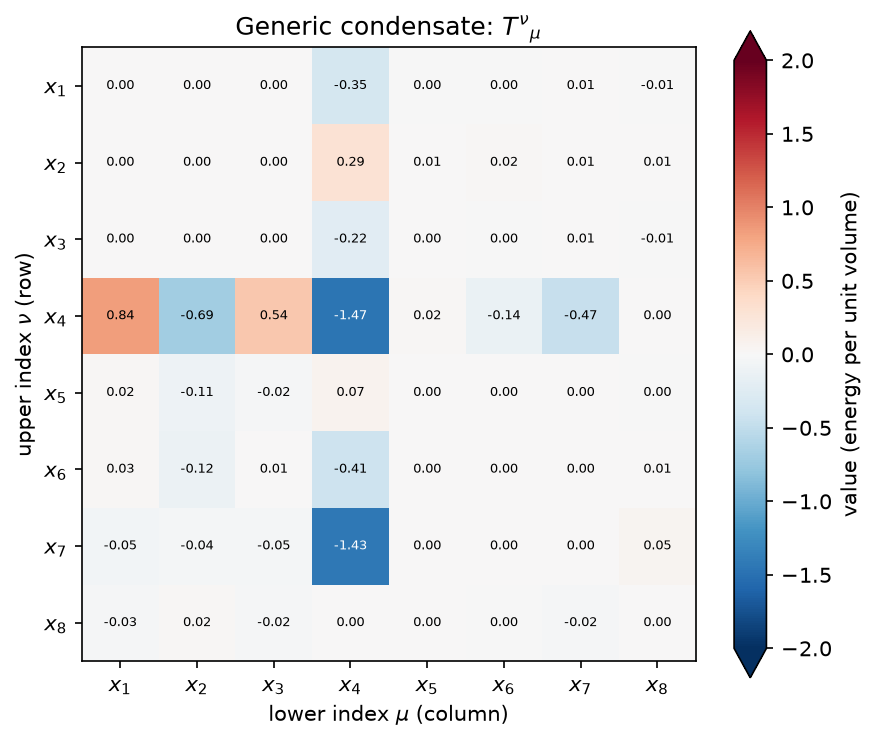

Figure 09c.1 saved as Revision/textbook/figures/09c_1_generic_condensate.png


In [4]:
def heat_map(ax, T, title, largest):
    """Draw T as coloured squares with the value printed in each."""
    picture = ax.imshow(T, cmap="RdBu_r", vmin=-largest, vmax=largest)
    for nu in range(8):
        for mu in range(8):
            text = f"{T[nu, mu]:.2f}"
            if text == "-0.00":  # a tiny negative number: print it as 0.00
                text = "0.00"
            # white digits on dark squares, black digits on light ones
            colour = "white" if abs(T[nu, mu]) > 0.6 * largest else "black"
            ax.text(mu, nu, text, ha="center", va="center", fontsize=6,
                    color=colour)
    ticks = [f"${n[0]}_{n[1]}$" for n in NAMES]
    ax.set_xticks(range(8), ticks)
    ax.set_yticks(range(8), ticks)
    ax.set_xlabel("lower index $\\mu$ (column)")
    ax.set_ylabel("upper index $\\nu$ (row)")
    ax.set_title(title)
    ax.grid(False)
    return picture


SCALE = 2.0  # the colour scale runs from -2 to 2 in both heat maps of this notebook
fig, ax = plt.subplots(figsize=(6.6, 5.6))
picture = heat_map(ax, T_generic, "Generic condensate: $T^\\nu{}_\\mu$", SCALE)
fig.colorbar(picture, ax=ax, label="value (energy per unit volume)", extend="both")
save_figure(fig, "generic_condensate",
            "Heat map of the 64 entries $T^\\nu{}_\\mu$ (row $\\nu$, column $\\mu$, "
            "both running over $x_1, \\dots, x_8$) of a generic exact condensate of "
            "dirac16complex00 with effective mass $V = 5$, $\\lambda = 0$, $H = 1$, "
            "a random unit column $\\chi$, at the point $a_4 = 0.5$, $a_4' = 0.25$, "
            "$z = \\pi/4$; colour scale from $-2$ to $2$ (entries beyond it are "
            "shown in the darkest colour and printed), in units of energy per unit "
            "volume. The diagonal holds only $-VS$ at $x_4$; 42 off-diagonal "
            "squares are nonzero, all of them produced by the spin connection. The "
            "squares $(x_4, x_8)$ and $(x_8, x_4)$ are zero.")

## 7. How the off-diagonal entries depend on the deflation rate

The next cell computes three off-diagonal entries of the same condensate at the
same point for 41 values of $a_4'$ from $-1$ to $1$: the momentum flow
$T^{x_4}{}_{x_1}$, the 3-space/extra-time entry $T^{x_1}{}_{x_5}$ and the
3-space/hidden entry $T^{x_1}{}_{x_8}$. The first does not depend on $a_4'$ (it
comes from the $H$ part of the spin connection); the other two are proportional
to $a_4'$, so they appear only because the extra times deflate (or, for
$a_4' < 0$, inflate). The cell checks both statements.

PASS T^x4_x1 does not depend on a4p and is not zero
PASS T^x1_x5 and T^x1_x8 are proportional to a4p (zero only at a4p = 0)
RESULT T^x4_x1 = 0.835532
RESULT slopes d T^x1_x5/d a4p and d T^x1_x8/d a4p = -0.012942 and -0.049288


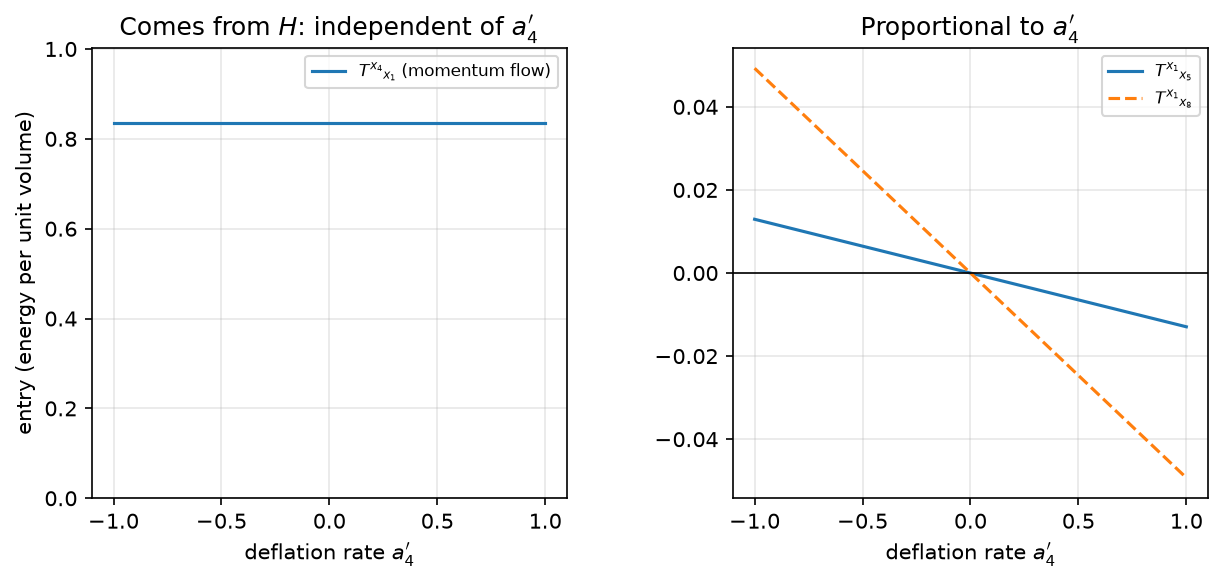

Figure 09c.2 saved as Revision/textbook/figures/09c_2_offdiagonal_entries.png


In [5]:
rates = np.linspace(-1.0, 1.0, 41)  # values of a4p
entries = np.array([[T[3, 0], T[0, 4], T[0, 7]] for T in (
    condensate_tensor(chi, POINT["a4"], rate, POINT["z"]) for rate in rates)])
check(np.abs(entries[:, 0] - entries[20, 0]).max() < 1e-12 and abs(entries[20, 0]) > 0.1,
      "T^x4_x1 does not depend on a4p and is not zero")
slopes = entries[-1, 1:] / rates[-1]  # the slope of each of the other two entries
check(np.abs(entries[:, 1:] - np.outer(rates, slopes)).max() < 1e-12
      and np.abs(slopes).min() > 1e-3,
      "T^x1_x5 and T^x1_x8 are proportional to a4p (zero only at a4p = 0)")
report("T^x4_x1", f"{entries[20, 0]:.6f}")
report("slopes d T^x1_x5/d a4p and d T^x1_x8/d a4p",
       f"{slopes[0]:.6f} and {slopes[1]:.6f}")
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.9))
fig.subplots_adjust(wspace=0.35)
left.plot(rates, entries[:, 0], label="$T^{x_4}{}_{x_1}$ (momentum flow)")
left.set_ylim(0.0, 1.2 * entries[20, 0])
left.set_xlabel("deflation rate $a_4'$")
left.set_ylabel("entry (energy per unit volume)")
left.set_title("Comes from $H$: independent of $a_4'$")
left.legend(fontsize=8)
right.plot(rates, entries[:, 1], label="$T^{x_1}{}_{x_5}$")
right.plot(rates, entries[:, 2], "--", label="$T^{x_1}{}_{x_8}$")
right.axhline(0.0, color="black", linewidth=0.8)
right.set_xlabel("deflation rate $a_4'$")
right.set_title("Proportional to $a_4'$")
right.legend(fontsize=8)
save_figure(fig, "offdiagonal_entries",
            "Three off-diagonal entries of the generic condensate of the previous "
            "figure ($V = 5$, $H = 1$, $a_4 = 0.5$, $z = \\pi/4$) against the "
            "deflation rate $a_4'$ from $-1$ to $1$, in units of energy per unit "
            "volume. Left: the momentum flow $T^{x_4}{}_{x_1}$ comes from the $H$ "
            "part of the spin connection and does not depend on $a_4'$. Right: "
            "$T^{x_1}{}_{x_5}$ (solid) and $T^{x_1}{}_{x_8}$ (dashed) are "
            "proportional to $a_4'$; at $a_4' = 0$ they vanish, and only the 12 "
            "momentum flows remain.")

## 8. The 15 three-gamma bilinears and the condensates with a diagonal tensor

**Each entry is one bilinear.** The record says that each of the 42 nonzero
off-diagonal entries is a multiple of one bilinear
$\bar\Phi\gamma^{(a)}\gamma^{(b)}\gamma^{(c)}\Phi$: for the pair $(\nu, \mu)$
the three directions are $\nu$, $\mu$ and the missing one of $x_4$, $x_8$ (or
$x_4$ when neither occurs). The next cell checks this by computing the ratio of
each entry to its bilinear for three different random columns: the ratio must
be the same number for all three (it depends on the point and on $V$, $H$, not on
the column). It also checks that exactly 15 bilinears occur.

**The witnesses.** The record builds condensates for which all 15 bilinears
vanish. The three matrices $P_1 = \gamma^{(1)}\gamma^{(5)}$,
$P_2 = \gamma^{(2)}\gamma^{(6)}$, $P_3 = \gamma^{(3)}\gamma^{(7)}$ square to 1 and
commute with each other and with $A$. Let $w = \sqrt{V^2 - 9H^2}$; then $A$ has
the eigenvalue $-iw$ on an 8-dimensional space. In that space take the unit
vector $v_1$ with $P_1 = P_2 = P_3 = -1$ and the unit vector $v_2$ with
$P_1 = P_2 = P_3 = +1$, put $c = \overline{v_1^\dagger Cv_2}$ (the bar means the
complex conjugate number) and $\Phi_0 = v_1 + cv_2$. The condensate is
$\Phi = e^{-iwx_4}\Phi_0$. The record gives three such witnesses,
$(V, H) = (5, 1)$, $(5, 4/3)$, $(-5, 1)$, with $w = 4$, $3$, $4$.

In [6]:
def bilinear_directions(nu, mu):
    """The three directions (a, b, c) of the bilinear that carries T^nu_mu."""
    directions = {nu, mu}
    if 3 in directions and 7 not in directions:
        directions.add(7)  # add x8
    elif 7 in directions and 3 not in directions:
        directions.add(3)  # add x4
    elif 3 not in directions and 7 not in directions:
        directions.add(3)  # add x4
    return tuple(sorted(directions))


def bilinear(column, directions):
    a, b, c = directions
    return bar(column) @ gamma[a] @ gamma[b] @ gamma[c] @ column


columns = [rng.normal(size=16) + 1j * rng.normal(size=16) for _ in range(3)]
tensors = [condensate_tensor(column, **POINT) for column in columns]
worst_ratio, used = 0.0, set()
for nu, mu in pairs:
    directions = bilinear_directions(nu, mu)
    used.add(directions)
    ratios = [tensors[n][nu, mu] / bilinear(columns[n], directions) for n in range(3)]
    worst_ratio = max(worst_ratio,
                      max(abs(r - ratios[0]) for r in ratios) / abs(ratios[0]))
check(worst_ratio < 1e-9 and len(used) == 15
      and recorded(A4_WL, "condensate_offdiagonal_are_three_gamma_bilinears") == "PASS"
      and recorded(A4_PY, "authorT16_condensate_offdiagonal_three_gamma") == "PASS",
      "each of the 42 entries is a fixed multiple of one of 15 three-gamma bilinears",
      record=f"{A4_WL}, check condensate_offdiagonal_are_three_gamma_bilinears; "
             f"{A4_PY}, check authorT16_condensate_offdiagonal_three_gamma")
for directions in sorted(used):
    say("bilinear Phibar gamma^(" + ") gamma^(".join(NAMES[d] for d in directions)
        + ") Phi")

PASS each of the 42 entries is a fixed multiple of one of 15 three-gamma bilinears
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    condensate_offdiagonal_are_three_gamma_bilinears;
    Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_condensate_offdiagonal_three_gamma
bilinear Phibar gamma^(x1) gamma^(x4) gamma^(x5) Phi
bilinear Phibar gamma^(x1) gamma^(x4) gamma^(x6) Phi
bilinear Phibar gamma^(x1) gamma^(x4) gamma^(x7) Phi
bilinear Phibar gamma^(x1) gamma^(x4) gamma^(x8) Phi
bilinear Phibar gamma^(x2) gamma^(x4) gamma^(x5) Phi
bilinear Phibar gamma^(x2) gamma^(x4) gamma^(x6) Phi
bilinear Phibar gamma^(x2) gamma^(x4) gamma^(x7) Phi
bilinear Phibar gamma^(x2) gamma^(x4) gamma^(x8) Phi
bilinear Phibar gamma^(x3) gamma^(x4) gamma^(x5) Phi
bilinear Phibar gamma^(x3) gamma^(x4) gamma^(x6) Phi
bilinear Phibar gamma^(x3) gamma^(x4) gamma^(x7) Phi
bilinear Phibar gamma^(x3) gamma^(x4) gamma^(x8) Phi
bilinear Phibar gamma^(x4) 

The next cell builds the three witnesses. The function `witness(V_w, H_w)` finds
the 8-dimensional space of $A$ for the eigenvalue $-iw$ (as the null space of
$A + iw$, from a singular value decomposition), then inside it the joint
eigenvectors $v_1$, $v_2$ (with the projector
$\frac18(1 \pm P_1)(1 \pm P_2)(1 \pm P_3)$, which keeps exactly the vectors with
$P_1 = P_2 = P_3 = \pm1$), and returns $w$ and $\Phi_0$. The cell checks that
$A\Phi_0 = -iw\Phi_0$, that all 15 bilinears vanish, that $S \neq 0$, and that the
tensor is diagonal at 36 points: every combination of $a_4 \in \{-1, 0, 0.5\}$,
$a_4' \in \{-0.5, 0, 0.25, 1\}$ and $z \in \{0.3, 0.8, 1.3\}$.

In [7]:
P = [gamma[i] @ gamma[i + 4] for i in range(3)]  # gamma^(x1) gamma^(x5), ...


def witness(V_w, H_w):
    """w and the column Phi0 of the record's diagonal witness for (V_w, H_w)."""
    A_w = -g4 @ (V_w * I16 - 3 * H_w * g8)
    w = np.sqrt(V_w ** 2 - 9 * H_w ** 2)
    _, singular, rows = np.linalg.svd(A_w + 1j * w * I16)
    space = rows[singular < 1e-9].conj().T  # 16 x 8: the eigenspace for -i w
    found = []
    for sign in (-1, 1):
        projector = (I16 + sign * P[0]) @ (I16 + sign * P[1]) @ (I16 + sign * P[2]) / 8
        left_vectors, values, _ = np.linalg.svd(projector @ space)
        if np.sum(values > 1e-9) != 1:
            raise ValueError("the joint eigenvector is not unique")
        found.append(left_vectors[:, 0])  # a unit vector
    v1, v2 = found
    c = np.conj(bar(v1) @ v2)
    return w, A_w, v1 + c * v2


WITNESSES = [(5.0, 1.0), (5.0, 4 / 3), (-5.0, 1.0)]
grid = [(a4, a4p, z) for a4 in (-1.0, 0.0, 0.5) for a4p in (-0.5, 0.0, 0.25, 1.0)
        for z in (0.3, 0.8, 1.3)]
witness_columns = {}
for V_w, H_w in WITNESSES:
    w, A_w, phi0 = witness(V_w, H_w)
    S_w = (bar(phi0) @ phi0).real
    largest_bilinear = max(abs(bilinear(phi0, d)) for d in used)
    worst_off = 0.0  # the largest off-diagonal entry at the 36 points
    for a4, a4p, z in grid:
        T = condensate_tensor(phi0, a4, a4p, z, V_w, H_w)
        worst_off = max(worst_off, np.abs(T - np.diag(np.diag(T))).max())
    check(np.abs(A_w @ phi0 + 1j * w * phi0).max() < 1e-12 and largest_bilinear < 1e-12
          and abs(S_w) > 0.1 and worst_off < 1e-12,
          f"witness (V, H) = ({V_w:g}, {H_w:.4g}): w = {w:g}, the 15 bilinears vanish, "
          "S != 0, T diagonal at 36 points")
    witness_columns[(V_w, H_w)] = phi0
    report(f"witness ({V_w:g}, {H_w:.4g}): w, and S for unit v1, v2",
           f"{w:g} and {S_w:.6f}")
check(recorded(A4_WL, "condensate_diagonal_witness_exact") == "PASS"
      and recorded(A4_PY, "authorT16_condensate_witness") == "PASS",
      "the three witnesses are the record's (w = 4, 3, 4)",
      record=f"{A4_WL}, check condensate_diagonal_witness_exact; {A4_PY}, check "
             "authorT16_condensate_witness")

PASS witness (V, H) = (5, 1): w = 4, the 15 bilinears vanish, S != 0, T diagonal at 36
    points
RESULT witness (5, 1): w, and S for unit v1, v2 = 4 and 1.280000
PASS witness (V, H) = (5, 1.333): w = 3, the 15 bilinears vanish, S != 0, T diagonal at
    36 points
RESULT witness (5, 1.333): w, and S for unit v1, v2 = 3 and 0.720000
PASS witness (V, H) = (-5, 1): w = 4, the 15 bilinears vanish, S != 0, T diagonal at 36
    points
RESULT witness (-5, 1): w, and S for unit v1, v2 = 4 and 1.280000
PASS the three witnesses are the record's (w = 4, 3, 4)
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    condensate_diagonal_witness_exact;
    Revision/field_equations_a4/reports/python-a4-report.json, check
    authorT16_condensate_witness


The next cell draws the tensor of the witness $(V, H) = (5, 1)$ at the same point
and with the same colour scale as the generic condensate: only one square is
coloured. (The value of $S$, and hence of $-VS$, depends on the length chosen
for $v_1$ and $v_2$; here both have length 1, while the record uses exact columns
of another length.)

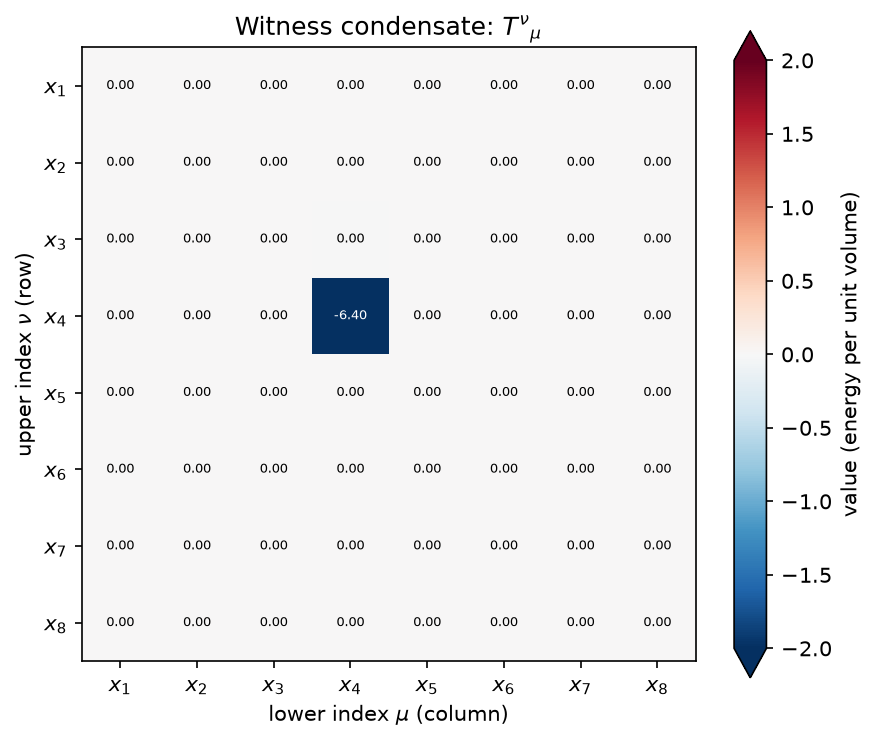

Figure 09c.3 saved as Revision/textbook/figures/09c_3_witness_condensate.png
PASS the drawn witness tensor is diagonal with T^x4_x4 = -V S != 0


In [8]:
T_witness = condensate_tensor(witness_columns[(5.0, 1.0)], **POINT)
fig, ax = plt.subplots(figsize=(6.6, 5.6))
picture = heat_map(ax, T_witness, "Witness condensate: $T^\\nu{}_\\mu$", SCALE)
fig.colorbar(picture, ax=ax, label="value (energy per unit volume)", extend="both")
save_figure(fig, "witness_condensate",
            "Heat map of the 64 entries $T^\\nu{}_\\mu$ of the exact witness "
            "condensate $\\Phi = e^{-4ix_4}\\Phi_0$ of the Revision record with "
            "$V = 5$, $H = 1$, $\\lambda = 0$, at the same point "
            "($a_4 = 0.5$, $a_4' = 0.25$, $z = \\pi/4$) and with the same colour "
            "scale as the generic condensate, in units of energy per unit volume. "
            "All 15 three-gamma bilinears of $\\Phi_0$ vanish, so every off-diagonal "
            "entry is zero (by the record, at every point of every history): this "
            "condensate is a perfect fluid at rest, with $T^{x_4}{}_{x_4} = -VS$ "
            "and zero pressure.")
check(len(off_diagonal_pairs(T_witness)) == 0 and abs(T_witness[3, 3]) > 0.1,
      "the drawn witness tensor is diagonal with T^x4_x4 = -V S != 0")

## 9. Conservation of the full tensor, tested with finite differences

The full tensor of a condensate, off-diagonal entries included, must satisfy
$\nabla_\mu T^\mu{}_\nu = 0$. Because the condensate solves the field equation on
every history, the test uses a non-linear one, $a_4 = 0.3x_4 + 0.05x_4^2$
($a_4' = 0.3 + 0.1x_4$), with $m = 1$, $\lambda = 0.5$, $H = 0.25$ and a random
unit column $\chi$. The tensor depends on $x_4$ (through $\Phi$, $a_4$ and $a_4'$)
and on $x_8$ (through $z$); the derivatives $\partial_4 T$ and $\partial_8 T$ are
taken by central finite differences with step $h$.

The next cell first computes the 25 Christoffel symbols of the metric with
sympy, puts the history into them and turns them into fast numpy functions
(`sp.lambdify`). Then `divergence(M, k2, x4, x8, h)` returns the eight
components of $\nabla_\mu T^\mu{}_\nu$ for the condensate built from the matrix
$M$. The true condensate uses $M = -V\gamma^{(4)} + 3H\gamma^{(4)}\gamma^{(8)}$;
the negative control uses $M = -V\gamma^{(4)}$, the condensate of an equation
without the gravitational term $3H\gamma^{(8)}$. Its $S$ is also constant, but
it does not solve the field equation of the author's metric, so its tensor must
not be conserved.

In [9]:
import sympy as sp  # exact algebra with symbols

x = sp.symbols("x1:9", real=True)
Hs = sp.symbols("H", positive=True)
a4_function = sp.Function("a4")(x[3])
zs = 6 * Hs * x[7]
space_entry = sp.exp(2 * a4_function) * sp.sin(zs) ** sp.Rational(1, 3)
extra_entry = -sp.exp(-2 * a4_function) * sp.sin(zs) ** sp.Rational(1, 3)
g = sp.diag(*([space_entry] * 3 + [-1] + [extra_entry] * 3 + [sp.cot(zs) ** 2]))
history = sp.Rational(3, 10) * x[3] + sp.Rational(1, 20) * x[3] ** 2  # a4(x4)
christoffel = {}  # (l, i, j) with i <= j -> a numpy function of (x4, x8, H)
for l in range(8):
    for i in range(8):
        for j in range(i, 8):
            value = sp.simplify((sp.diff(g[l, j], x[i]) + sp.diff(g[l, i], x[j])
                                 - sp.diff(g[i, j], x[l])) / (2 * g[l, l]))
            if value != 0:  # put the history in, then make a numpy function
                christoffel[(l, i, j)] = sp.lambdify(
                    (x[3], x[7], Hs), value.subs(a4_function, history).doit(), "numpy")
check(len(christoffel) == 25, "25 nonzero Christoffel symbols (i <= j)")
m9, lam9, H9 = 1.0, 0.5, 0.25  # the parameters of this section
chi9 = rng.normal(size=16) + 1j * rng.normal(size=16)
chi9 /= np.linalg.norm(chi9)
V9 = m9 + lam9 * (bar(chi9) @ chi9).real  # the effective mass
M_TRUE = -V9 * g4 + 3 * H9 * g4 @ g8  # the true condensate: M^2 = 9 H^2 - V^2
M_CONTROL = -V9 * g4  # without the term 3 H gamma^(x8): M^2 = -V^2
K2_TRUE, K2_CONTROL = 9 * H9 ** 2 - V9 ** 2, -V9 ** 2


def field(M, k2, x4):
    """Phi(x4) and dPhi/dx4 = M Phi(x4) for Phi(0) = chi9 (M^2 = k2)."""
    k = np.sqrt(complex(k2))
    phi = np.cosh(k * x4) * chi9 + np.sinh(k * x4) / k * (M @ chi9)
    return phi, M @ phi


def tensor_at(M, k2, x4, x8):
    phi, d4 = field(M, k2, x4)
    dphi = np.zeros((8, 16), dtype=complex)
    dphi[3] = d4
    return energy_momentum(phi, dphi, m9, lam9, 0.3 * x4 + 0.05 * x4 ** 2,
                           0.3 + 0.1 * x4, 6 * H9 * x8, H9)


def divergence(M, k2, x4, x8, h):
    """The eight components of nabla_mu T^mu_nu, with central differences of step h,
    and the size of the tensor (its largest entry)."""
    T = tensor_at(M, k2, x4, x8)
    d4T = (tensor_at(M, k2, x4 + h, x8) - tensor_at(M, k2, x4 - h, x8)) / (2 * h)
    d8T = (tensor_at(M, k2, x4, x8 + h) - tensor_at(M, k2, x4, x8 - h)) / (2 * h)
    G = np.zeros((8, 8, 8))  # G[l, i, j] = Gamma^l_ij
    for (l, i, j), function in christoffel.items():
        G[l, i, j] = G[l, j, i] = function(x4, x8, H9)
    result = np.zeros(8)
    for nu in range(8):
        result[nu] = (d4T[3, nu] + d8T[7, nu]  # d_mu T^mu_nu (only x4 and x8)
                      + np.einsum("mml,l->", G, T[:, nu])  # Gamma^mu_mu l T^l_nu
                      - np.einsum("lm,ml->", G[:, :, nu], T))  # Gamma^l_mu nu T^mu_l
    return result, np.abs(T).max()

PASS 25 nonzero Christoffel symbols (i <= j)


The next cell computes the largest of the eight components of the divergence for
eleven steps $h$ from $0.2$ down to $0.0002$ at the point $x_4 = 1$, $z = 0.5$,
for the true condensate and for the control. For the true condensate the result
must fall like $h^2$ (each halving of $h$ divides it by about 4): the exact
divergence is zero and only the error of the finite differences is left. For the
control it must approach a nonzero value. The cell also checks the true
condensate at two more points with $h = 0.001$ and $h = 0.0001$: the divergence
must shrink about a hundredfold and end below $10^{-5}$ of the size of the tensor.

In [10]:
steps = 0.2 / 2.0 ** np.arange(11)  # 0.2, 0.1, ..., about 0.0002
X4_TEST, X8_TEST = 1.0, 0.5 / (6 * H9)  # x4 = 1 and z = 0.5
true_sizes, control_sizes = [], []
for h in steps:
    div_true, size_true = divergence(M_TRUE, K2_TRUE, X4_TEST, X8_TEST, h)
    div_control, _ = divergence(M_CONTROL, K2_CONTROL, X4_TEST, X8_TEST, h)
    true_sizes.append(np.abs(div_true).max())
    control_sizes.append(np.abs(div_control).max())
true_sizes, control_sizes = np.array(true_sizes), np.array(control_sizes)
ratios = true_sizes[:6] / true_sizes[1:7]  # halving h from 0.2 to 0.003125
check(np.all((ratios > 3.6) & (ratios < 4.4)),
      "true condensate: halving h divides the divergence by about 4 (error h^2)")
check(true_sizes[8] < 1e-6 * size_true,
      "true condensate: the divergence falls below 1e-6 of the tensor's size")
check(abs(control_sizes[-1] / control_sizes[-2] - 1) < 1e-3
      and control_sizes[-1] > 1e-2 * size_true,
      "control: the divergence tends to a nonzero value (it is not conserved)")
for x4_point, z_point in ((2.0, 1.0), (0.5, 1.2)):
    x8_point = z_point / (6 * H9)
    coarse, size_other = divergence(M_TRUE, K2_TRUE, x4_point, x8_point, 1e-3)
    fine, _ = divergence(M_TRUE, K2_TRUE, x4_point, x8_point, 1e-4)
    shrink = np.abs(coarse).max() / np.abs(fine).max()  # about 10^2 for an h^2 error
    check(90 < shrink < 110 and np.abs(fine).max() < 1e-5 * size_other,
          f"true condensate conserved at x4 = {x4_point}, z = {z_point} "
          "(h = 0.001 and 0.0001)")
WL = "Revision/theory/reports/wolfram-field-theory.json"
check(recorded(WL, "exact_solution_nonlinear_homogeneous_C") == "PASS"
      and recorded(WL, "conservation_on_shell_general") == "PASS",
      "the record proves the conservation that these numbers confirm",
      record=f"{WL}, checks exact_solution_nonlinear_homogeneous_C and "
             "conservation_on_shell_general")
for h, t_size, c_size in zip(steps[::2], true_sizes[::2], control_sizes[::2]):
    say(f"h = {h:.5f}:  true condensate {t_size:.2e},  control {c_size:.4f}")

PASS true condensate: halving h divides the divergence by about 4 (error h^2)
PASS true condensate: the divergence falls below 1e-6 of the tensor's size
PASS control: the divergence tends to a nonzero value (it is not conserved)
PASS true condensate conserved at x4 = 2.0, z = 1.0 (h = 0.001 and 0.0001)
PASS true condensate conserved at x4 = 0.5, z = 1.2 (h = 0.001 and 0.0001)
PASS the record proves the conservation that these numbers confirm
     reproduces Revision/theory/reports/wolfram-field-theory.json, checks
    exact_solution_nonlinear_homogeneous_C and conservation_on_shell_general
h = 0.20000:  true condensate 5.06e-03,  control 0.0729
h = 0.05000:  true condensate 2.94e-04,  control 0.0679
h = 0.01250:  true condensate 1.83e-05,  control 0.0676
h = 0.00313:  true condensate 1.14e-06,  control 0.0676
h = 0.00078:  true condensate 7.16e-08,  control 0.0676
h = 0.00020:  true condensate 4.47e-09,  control 0.0676


The next cell draws the two series on logarithmic axes, with a line proportional
to $h^2$ for comparison.

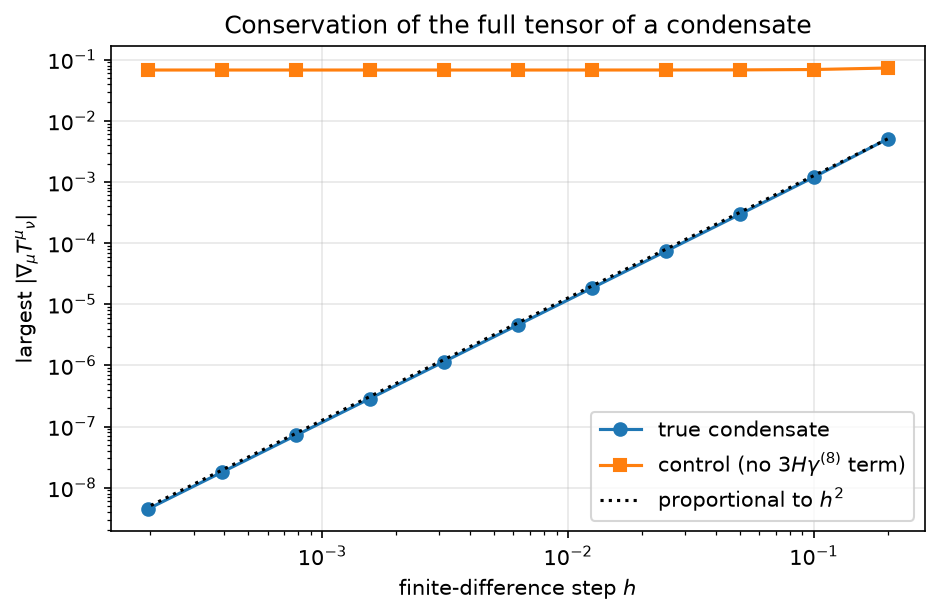

Figure 09c.4 saved as Revision/textbook/figures/09c_4_conservation_convergence.png


In [11]:
fig, ax = plt.subplots()
ax.loglog(steps, true_sizes, "o-", label="true condensate")
ax.loglog(steps, control_sizes, "s-", label="control (no $3H\\gamma^{(8)}$ term)")
ax.loglog(steps, true_sizes[0] * (steps / steps[0]) ** 2, "k:",
          label="proportional to $h^2$")
ax.set_xlabel("finite-difference step $h$")
ax.set_ylabel("largest $|\\nabla_\\mu T^\\mu{}_\\nu|$")
ax.set_title("Conservation of the full tensor of a condensate")
ax.legend()
save_figure(fig, "conservation_convergence",
            "The largest of the eight components of the covariant divergence "
            "$\\nabla_\\mu T^\\mu{}_\\nu$ of the full tensor of a condensate "
            "($m = 1$, $\\lambda = 0.5$, $H = 0.25$, history "
            "$a_4 = 0.3x_4 + 0.05x_4^2$, point $x_4 = 1$, $z = 0.5$), computed with "
            "central finite differences of step $h$, against $h$ from $0.2$ to "
            "$0.0002$; both axes logarithmic, the divergence in units of energy per "
            "unit volume per unit length. For the true condensate (circles) it "
            "falls like $h^2$ (dotted line): the exact divergence is zero. For the "
            "control (squares), which leaves out the term $3H\\gamma^{(8)}$ of the "
            "field equation, it stays near $0.07$: its tensor is not conserved.")

The next cell draws the eight components separately at the step $h = 0.001$, for
the true condensate and for the control, as bars on a logarithmic axis, and
checks what the picture shows: the control fails in the six momentum components
(along 3-space and the extra times), while its energy component $\nu = x_4$ and
its hidden component $\nu = x_8$ vanish. The control's energy density and
pressures are the same as those of the true condensate (its $S$ is constant and
$p_3 = p_t$), so its energy balance holds; it is the momentum balance that the
missing term $3H\gamma^{(8)}$ breaks.

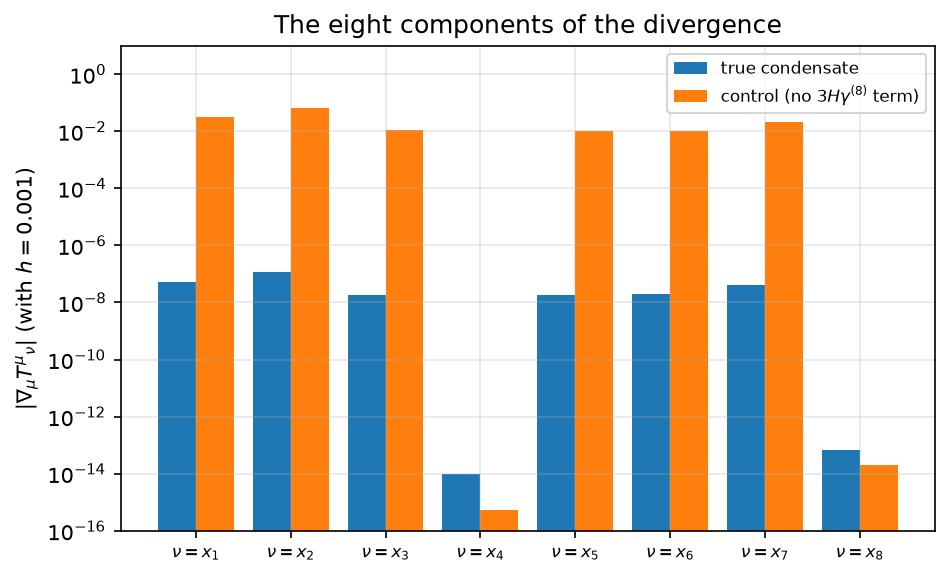

Figure 09c.5 saved as Revision/textbook/figures/09c_5_divergence_components.png
PASS control: its six momentum components are nonzero (over 1000 times the true
    condensate's), its x4 and x8 components vanish


In [12]:
div_true, _ = divergence(M_TRUE, K2_TRUE, X4_TEST, X8_TEST, 1e-3)
div_control, _ = divergence(M_CONTROL, K2_CONTROL, X4_TEST, X8_TEST, 1e-3)
positions = np.arange(8)
fig, ax = plt.subplots()
floor = 1e-16  # zero components are drawn at this height on the logarithmic axis
ax.bar(positions - 0.2, np.abs(div_true) + floor, width=0.4, label="true condensate")
ax.bar(positions + 0.2, np.abs(div_control) + floor, width=0.4,
       label="control (no $3H\\gamma^{(8)}$ term)")
ax.set_yscale("log")
ax.set_ylim(1e-16, 10.0)
ax.set_xticks(positions, [f"$\\nu = {n[0]}_{n[1]}$" for n in NAMES], fontsize=8)
ax.set_ylabel("$|\\nabla_\\mu T^\\mu{}_\\nu|$ (with $h = 0.001$)")
ax.set_title("The eight components of the divergence")
ax.legend(fontsize=8)
save_figure(fig, "divergence_components",
            "The eight components $|\\nabla_\\mu T^\\mu{}_\\nu|$, $\\nu = x_1, \\dots, "
            "x_8$, of the divergence of the full tensor of the condensate of the "
            "previous figure, with finite differences of step $h = 0.001$, on a "
            "logarithmic axis (components that vanish exactly are drawn at "
            "$10^{-16}$). The true condensate (left bars) has every component at the "
            "level of the finite-difference error, below $10^{-6}$. The control "
            "(right bars) has its six momentum components $\\nu = x_1, x_2, x_3, "
            "x_5, x_6, x_7$ between about $0.01$ and $0.07$, while its components "
            "$\\nu = x_4$ and $x_8$ vanish like those of the true condensate: the "
            "control keeps the energy balance but breaks the momentum balance along "
            "3-space and the extra times.")
momentum = [0, 1, 2, 4, 5, 6]  # the components nu = x1, x2, x3, x5, x6, x7
check(np.abs(div_control).max() > 1e3 * np.abs(div_true).max()
      and np.abs(div_control[momentum]).min() > 1e-3
      and max(abs(div_control[3]), abs(div_control[7])) < 1e-9,
      "control: its six momentum components are nonzero (over 1000 times the true "
      "condensate's), its x4 and x8 components vanish")

## 10. The last check

The last cell checks that the five figures are saved with their captions and
prints the number of checks that passed.

In [13]:
captions = json.loads(output_file(CAPTION_FILE).read_text(encoding="utf-8"))
expected_files = ["09c_1_generic_condensate.png", "09c_2_offdiagonal_entries.png",
                  "09c_3_witness_condensate.png",
                  "09c_4_conservation_convergence.png",
                  "09c_5_divergence_components.png"]
check(sorted(captions) == expected_files and all(
    output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in expected_files),
    "the five figures of this notebook are saved and captioned")
all_checks_passed()

PASS the five figures of this notebook are saved and captioned
ALL 20 CHECKS PASSED (notebook 09c)


## 11. What this notebook showed

- A generic exact condensate of dirac16complex00 has the diagonal of a perfect
  fluid ($-VS$ at $x_4$, the same pressure elsewhere, zero for $\lambda = 0$) but
  42 nonzero off-diagonal entries, all produced by the spin connection: 12
  momentum flows that come from $H$, and 30 more that are proportional to the
  deflation rate $a_4'$. Its $x_4$-$x_8$ entries vanish.
- Each off-diagonal entry is a fixed multiple of one of 15 three-gamma bilinears
  (the record's statement, confirmed with three random columns).
- The record's witnesses, built from joint eigenvectors of
  $\gamma^{(1)}\gamma^{(5)}$, $\gamma^{(2)}\gamma^{(6)}$, $\gamma^{(3)}\gamma^{(7)}$,
  make all 15 bilinears vanish: their tensor is diagonal (the record shows it for
  every $a_4$ and $a_4'$; this notebook checked 36 points). On the deflating
  history only such special condensates meet the condition of the $a_4$ field
  equations that the off-diagonal entries of the source vanish (one condition
  among several).
- The full tensor of a condensate is conserved, $\nabla_\mu T^\mu{}_\nu = 0$,
  along a curved history: the finite-difference divergence falls like $h^2$. A
  configuration that leaves out the gravitational term $3H\gamma^{(8)}$ keeps the
  energy balance but breaks the six momentum balances along 3-space and the
  extra times: the term is needed for the conservation of the tensor.
- Status: the statements are PROVED in the Revision record (exact, Wolfram and
  sympy); this notebook confirms them numerically. The parameter values are
  choices of this notebook.